# Import libraries

In [2]:
# data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# time
import time

# dataset
from sklearn.datasets import load_breast_cancer

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Load dataset

In [3]:
data = load_breast_cancer(as_frame=True)
df = data.frame

# Data exploration

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


# Feature and target

In [8]:
X = df.drop('target', axis=1)
y = df['target']

# Train-test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42,stratify=y)

# Baseline Decision Tree

In [10]:
baseline_DTC = DecisionTreeClassifier(random_state=42)
baseline_DTC.fit(X_train,y_train)
predict_baseline_DTC = baseline_DTC.predict(X_test)

# Bagging Classifier

A Bagging Classifier (Bootstrap Aggregating) is a machine learning ensemble meta-estimator. It trains multiple "weak" base models—typically decision trees—on random subsets of data sampled with replacement. Final predictions are made by combining individual results through a majority vote, which reduces variance and prevents overfitting.

In [11]:
# n_estimators: The number of base models to train in the ensemble.
# More is generally better for stability, but increases computing time.
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,random_state=42)
bagging.fit(X_train, y_train)
predict_bagging = bagging.predict(X_test)

# Random forest

In [12]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
predict_rf = rf.predict(X_test)

AdaBoost

Adaptive Boosting, also known as AdaBoost, is a strategy in machine learning that aims to improve the accuracy of an ensemble by creating a series of classifiers. It focuses more on misclassified data points in each round, leading to the creation of a strong classifier by combining multiple weak learners.

In [13]:
# Sequential learning.
ada = AdaBoostClassifier(n_estimators=200, random_state=42)
ada.fit(X_train, y_train)
predict_ada= ada.predict(X_test)

# Gradient Boosting

A Gradient Boosting Classifier is a powerful ensemble machine learning algorithm that builds predictive models sequentially. It combines multiple "weak learners" (usually shallow decision trees) into a single, strong prediction model by training each new tree to correct the errors—or pseudo-residuals—of the previous ones.

In [14]:
# Gradient descent on residual errors.
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
predict_gb = gb.predict(X_test)

# XGBoost

XGBoost (eXtreme Gradient Boosting) is an open-source machine learning library designed to push the limits of computing power for boosted tree algorithms. Renowned for its speed, scalability, and predictive power, it is widely used for classification, regression, and ranking problems on structured data

In [15]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
predict_xgb = xgb.predict(X_test)

# LightGBM

LightGBM (Light Gradient Boosting Machine) is a highly efficient, distributed gradient boosting framework developed by Microsoft. It excels in speed, scalability, and memory usage, making it ideal for large-scale datasets and real-time machine learning tasks across regression, classification, and ranking problems.

In [16]:
lgbm = LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train, y_train)
predict_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

# CatBoost

CatBoost (Categorical Boosting) is a high-performance open-source machine learning algorithm based on gradient-boosted decision trees. Developed by Yandex, it is famous for natively handling categorical variables and delivering state-of-the-art accuracy with little to no parameter tuning.

In [17]:
cat =CatBoostClassifier(verbose=False, random_state=42)
cat.fit(X_train, y_train)
predict_cat = cat.predict(X_test)

# Model evaluation

In [18]:
results = []

def evaluate_model(name, model):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    predicts = model.predict(X_test)


    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predicts),
        "Precision": precision_score(y_test, predicts),
        "Recall": recall_score(y_test, predicts),
        "F1 score": f1_score(y_test, predicts),
        "ROC_AUC": roc_auc_score(y_test, predicts),
        "Training time (s)": train_time
    })

In [19]:
evaluate_model("Decision Tree", baseline_DTC)
evaluate_model("Bagging", bagging)
evaluate_model("Random Forest", rf)
evaluate_model("AdaBoost", ada)
evaluate_model("Gradient Boosting", gb)
evaluate_model("XGBoost", xgb)
evaluate_model("LightGBM", lgbm)
evaluate_model("CatBoost", cat)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

# Comparison table

In [21]:
comparison = pd.DataFrame(results)
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 score,ROC_AUC,Training time (s)
3,AdaBoost,0.964912,0.947368,1.000000,0.972973,0.952381,0.304123
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.950397,0.188534
5,XGBoost,0.956140,0.946667,0.986111,0.965986,0.945437,0.040267
4,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.945437,0.411515
6,LightGBM,0.956140,0.946667,0.986111,0.965986,0.945437,0.052235
7,CatBoost,0.956140,0.946667,0.986111,0.965986,0.945437,2.321808
1,Bagging,0.938596,0.945205,0.958333,0.951724,0.931548,0.248390
0,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675,0.005522


# Visualiza performance

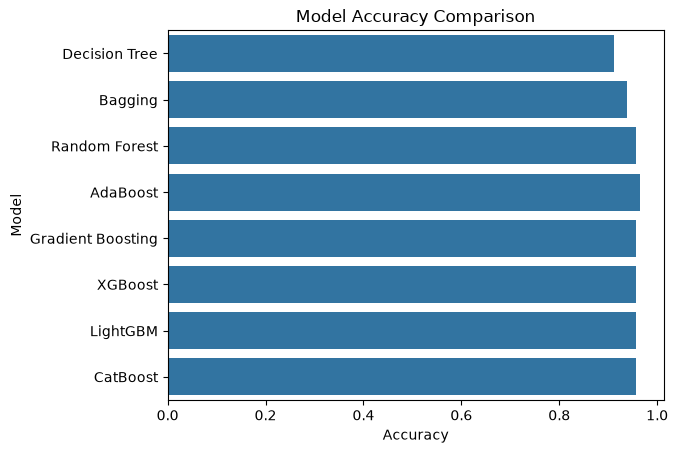

In [22]:
sns.barplot(data=comparison, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.show()

# ROC_AUC

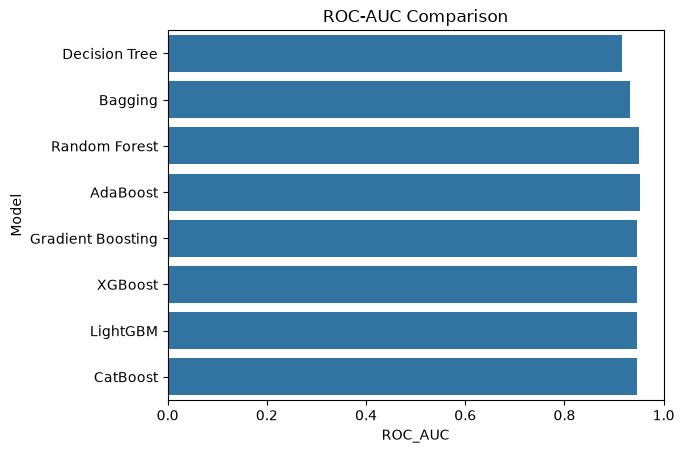

In [23]:
sns.barplot(
    data=comparison,
    x="ROC_AUC",
    y="Model"
)
plt.title("ROC-AUC Comparison")
plt.show()

# Training time

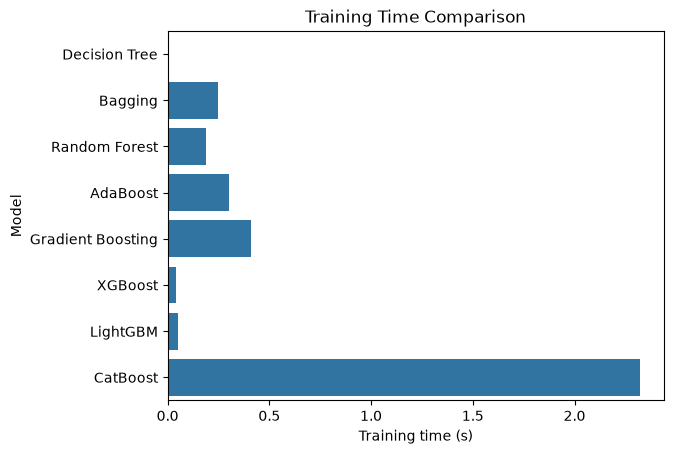

In [24]:
sns.barplot(
    data=comparison,
    x="Training time (s)",
    y="Model"
)

plt.title("Training Time Comparison")
plt.show()

# Feature Importance

Use the best-performing tree-based model (e.g., AdaBoost).

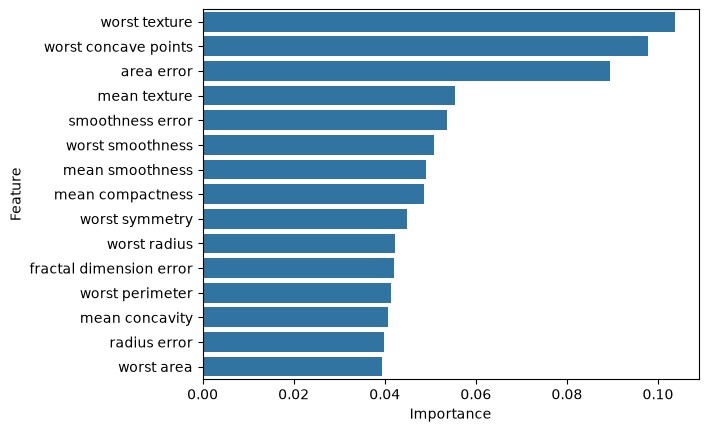

In [28]:
importance = pd.DataFrame({"Feature": X.columns,"Importance":ada.feature_importances_})
importance_sorted = importance.sort_values("Importance",ascending=False)
sns.barplot(data=importance_sorted.head(15), x="Importance", y="Feature")
plt.show()

# Bias–Variance Discussion

| Model             | Bias     | Variance | Notes                               |
| ----------------- | -------- | -------- | ----------------------------------- |
| Decision Tree     | Low      | High     | Can overfit                         |
| Bagging           | Lower    | Lower    | Reduces variance                    |
| Random Forest     | Low      | Lower    | Strong generalization               |
| AdaBoost          | Moderate | Moderate | Focuses on hard samples             |
| Gradient Boosting | Low      | Moderate | Sequential learning                 |
| XGBoost           | Low      | Moderate | Regularized boosting                |
| LightGBM          | Low      | Moderate | Optimized for speed                 |
| CatBoost          | Low      | Moderate | Excellent with categorical features |
